In [31]:
import numpy as np
import h5py
import time
import inspect

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from helpers.gw_shapes import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from dataset_generation.noise_psd_gen import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, HDF5Glitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Ollie's method

In [32]:
import datetime
import logging

from lisainstrument import Instrument
from lisaorbits import OEMOrbits

from pytdi import Data
from pytdi.intervar import compute_etas
from pytdi.michelson import compute_factorized_michelson

In [33]:
def build_instrument_config(pipe, orbits_path, gw_path=None, glitch_path=None, seed=None):
    instru_t0 = pipe['t0']
    instru_dt = pipe['dt']
    instru_size = pipe['size']

    instru_config = {
        # Random seed
        "seed": seed,
        # Sampling parameters
        "size": instru_size,
        "dt": instru_dt,
        "t0": instru_t0,
        # Physics simulation sampling and filtering
        "physics_upsampling": 4,
        "aafilter": ("kaiser", 240, 1.1, 2.9),
        "noises_f_min_hz": 5e-6,
        # Telemetry sampling
        "telemetry_downsampling": 86400 * 4,
        "initial_telemetry_size": 0,
        # Inter-spacecraft propagation
        "orbits": orbits_path,
        "orbit_dataset": "tcb/ltt",
        "gws": gw_path,
        "interpolation": ("lagrange", 31),
        # Artifacts
        "glitches": glitch_path,
        # Laser locking and frequency plan
        "lock": "six",
        "fplan": "static",
        "laser_asds": 0.0,
        "laser_shape": "white",
        "central_freq": 2.816e14,
        "offset_freqs": {
            "12": 0.0,
            "23": 11e6,
            "31": 7.5e6,
            "13": 16e6,
            "32": -12e6,
            "21": -7e6,
        },
        # Laser phase modulation
        "modulation_asds": 0.0,
        "modulation_freqs": 0.0,
        "tdir_modulations": None,
        # Clocks
        "clock_asds": 0.0,
        "clock_offsets": 0.0,
        "clock_freqoffsets": 0.0,
        "clock_freqlindrifts": 0.0,
        "clock_freqquaddrifts": 0.0,
        "clock_f_min_hz": 5e-6,
        # Clock inversion
        "clockinv_tolerance": 1e-10,
        "clockinv_maxiter": 5,
        # Optical pathlength noises
        "backlink_asds": 0.0,
        "backlink_fknees": 0.0,
        "testmass_asds": 3.0e-15,
        "testmass_fknees": 0.4e-3,
        "testmass_fbreak": 8e-3,
        "testmass_frelax": 0.0,
        "testmass_shape": "original",
        "oms_asds": (15.0e-12, 0.0, 0.0, 0.0, 0.0, 0.0),
        "oms_fknees": 2e-3,
        # MOC time correlation
        "moc_time_correlation_asds": 0.0,
        # Tilt-to-length (TTL)
        "ttl_coeffs": (0.0, 0.0, 0.0, 0.0),
        "sc_angular_jitter_asds": (0.0, 0.0, 0.0),
        "sc_angular_jitter_fknees": (0.0, 0.0, 0.0),
        "mosa_angular_jitter_asds": (0.0, 0.0),
        "mosa_angular_jitter_fknees": (0.0, 0.0),
        "mosa_angles": {
            "12": 30, "23": 30, "31": 30, "13": -30, "32": -30, "21": -30
        },
        "dws_asds": 0.0,
        # Lateral jitters
        "mosa_longitudinal_jitter_asds": 0.0,
        # Pseudo-ranging
        "ranging_biases": 0,
        "ranging_asds": 0.0,
        "prn_ambiguity": None,
        # Electronic delays
        "electro_delays": (0, 0, 0),
    }
    return instru_config

In [34]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

In [61]:
pipe = {'t0': orb_t0+ 0.01*orb_size*orb_dt, 'dt': 0.25,'size': int(10 * 3600 / 0.25)}

amp = 5e-13
beta = 50
inj_point = 'tm_23'

if os.path.exists(glitch_path):
    os.remove(glitch_path)

glitch = IntegratedShapeletGlitch(level=2*amp*beta, beta=beta, 
                                    inj_point=inj_point, t_inj=5*3600 + pipe['t0'])

glitch.write(path=glitch_path, mode="a", t0=pipe['t0'], size=pipe['size'], dt=pipe['dt'])

In [37]:
if os.path.exists(gw_path):
    os.remove(gw_path)

gw = {'type': 'BinaryInspiralGW', 'm1': 25282.644286804687, 'm2': 11326.092363067513, 'd': 6681.557987609389,
        'spin1': 0, 'spin2': 0, 't_inj': 6*3600, 'iota': 0, 'gw_beta':0, 'gw_lambda':0}

gw = BinaryInspiralGW(m1=gw['m1'], m2=gw['m2'], d=gw['d'], t_inj=gw['t_inj'] + pipe['t0'],
                                  spin1 = gw['spin1'], spin2 = gw['spin2'],
                        gw_beta=gw['gw_beta'], gw_lambda=gw['gw_lambda'], orbits=orbits_path)

gw.write(path=gw_path, mode="a", dt=pipe['dt'], size=pipe['size'], t0=pipe['t0'])

You are using an orbit file in a version that might not be fully supported


Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported


In [62]:
instru_config = build_instrument_config(pipe, orbits_path, gw_path=None, glitch_path=glitch_path, seed=42)
instru = Instrument(**instru_config)
instru.export_hdf5(simulation_path, overwrite=True)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz


In [64]:
TDI_ORDER = 45
data = Data.from_instrument(simulation_path)
eta_vars = compute_etas(data, order=TDI_ORDER, unit="frequency")

You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [65]:
raw_dict = {}
channels = ['X', 'Y', 'Z']

for i in range(len(channels)):
    raw_dict[channels[i]] = compute_factorized_michelson(
        data, etas=eta_vars, order=TDI_ORDER, generation=2, rot=i, unit="frequency")

In [66]:
A,E,T = get_AET(raw_dict['X'], raw_dict['Y'], raw_dict['Z'])
raw_dict['A'] = A
raw_dict['E'] = E
raw_dict['T'] = T

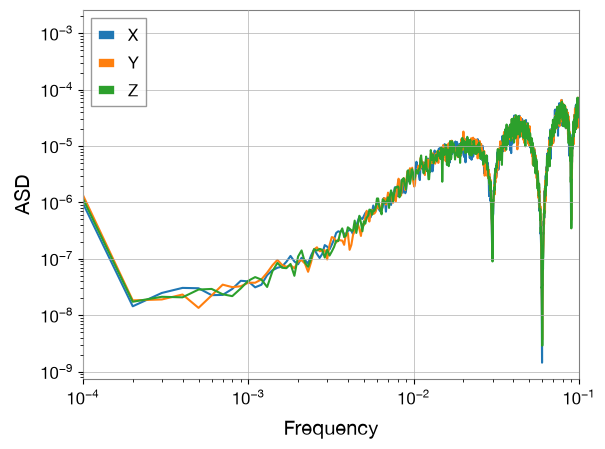

In [30]:
channels = ['X', 'Y', 'Z']

for channel in channels:
    f_psd, psd = estimate_psd(raw_dict[channel], 1/pipe['dt'], nperseg=1e4/pipe['dt'], noverlap=None)

    plt.plot(f_psd, np.sqrt(psd), label=channel)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 1e-1)
plt.xlabel('Frequency')
plt.ylabel('ASD')
plt.legend()
plt.show()

In [42]:
def generate_qscan(tdi_dict, channel, dt, event, 
                   frange, trange, Q, resolution):

    signal = TimeSeries(tdi_dict[channel], dt=dt, t0=0)
    
    time_secs = signal.times.value
    time_hrs = time_secs/3600
    
    index = np.where((time_hrs <= event/3600 + trange[1]) & (time_hrs >= event/3600 + trange[0]))[0]
    sigslice = signal[index].value
    timeslice = signal[index].times.value
    
    t_arr, f_arr, QT = q_transform(timeslice, sigslice, Q=Q, resolution=resolution,
                        frange=frange, trange=(np.min(timeslice),np.max(timeslice)))

    return t_arr, f_arr, QT

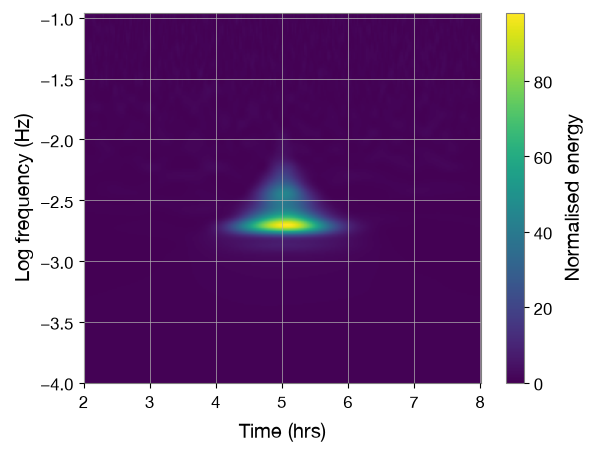

In [68]:
t_axis, f_axis, QT = generate_qscan(raw_dict, 'A', pipe['dt'], 5*3600, resolution=256,
                             frange=(1e-4, 1e-1), trange=(-3, 3), Q=16)

plt.imshow(QT, extent=[t_axis[0]/3600, t_axis[-1]/3600, np.log10(f_axis[0]), np.log10(f_axis[-1])],\
     aspect='auto', origin='lower')

plt.xlabel('Time (hrs)')
plt.ylabel('Log frequency (Hz)')
plt.colorbar(label='Normalised energy')
plt.show()